In [1]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
import utils_2Q_gate_zp as ut
import qutip as qt
import scqubits as scq
from scipy.ndimage import gaussian_filter
import scipy as sp
from IPython.display import display, Math
import pandas as pd
from joblib import Parallel, delayed
from multiprocessing import Pool

In [15]:
truncation, truc1 = 1000, 300
folder = '../../data/3ncut_one_zeropi/'
eval0 = 2*np.pi* scq.read(folder + f'zeropi_0_specdata_truc={truncation}_3ncut.h5').energy_table
n_theta0 =  2*np.pi* scq.read(folder + f'zeropi_0_n_theta_truc={truncation}_3ncut.h5').matrixelem_table
n_phi0 = 2*np.pi* scq.read(folder + f'zeropi_0_n_phi_truc={truncation}_3ncut.h5').matrixelem_table
eval0 = eval0 - eval0[0]

In [16]:
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [39.991616,0.105045,0.028058,0.002171,0.003988] # theta
w_0_7 = np.abs( eval0[7] - eval0[0] )
w_2_7 = np.abs( eval0[7] - eval0[2] )
wd1_theta = w_0_7 + 2 * np.pi * detune_A
wd2_theta = w_2_7 + 2 * np.pi * detune_B
print('wd1_theta=', wd1_theta)
print('wd2_theta=', wd2_theta)
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [120.004766,0.209273,0.104767,0.341188,0.360503] # phi
w_0_9 = np.abs( eval0[9] - eval0[0] )
w_2_9 = np.abs( eval0[9] - eval0[2] )
wd1_phi = w_0_9 + 2 * np.pi * detune_A
wd2_phi = w_2_9 + 2 * np.pi * detune_B
print('wd1_phi=', wd1_phi)
print('wd2_phi=', wd2_phi)

wd1_theta= 43.886546449876825
wd2_theta= 22.51927991686371
wd1_phi= 53.03760492799986
wd2_phi= 31.780281571491773


wd1_phi= 53.03760492799986
wd2_phi= 31.780281571491773


In [7]:
ut.print_trans_freq(0, 7, evals, n_Theta=n_theta0)
ut.print_trans_freq(2, 7, evals, n_Theta=n_theta0)
ut.print_trans_freq(7, 25, evals, n_Theta=n_theta0)
ut.print_trans_freq(0, 1, evals, n_Theta=n_theta0)
ut.print_trans_freq(2, 4, evals, n_Theta=n_theta0)
ut.print_trans_freq(2, 5, evals, n_Theta=n_theta0)
ut.print_trans_freq(1, 4, evals, n_Theta=n_theta0)
ut.print_trans_freq(7, 11, evals, n_Theta=n_theta0)

ut.print_trans_freq(0, 9, evals, n_Phi=n_phi0)
ut.print_trans_freq(2, 9, evals, n_Phi=n_phi0)
ut.print_trans_freq(0, 10, evals, n_Phi=n_phi0)
ut.print_trans_freq(9, 33, evals, n_Phi=n_phi0)
ut.print_trans_freq(2, 19, evals, n_Phi=n_phi0)
ut.print_trans_freq(19, 56, evals, n_Phi=n_phi0)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [10]:
truncation=10
ncut, phi_cut = 20, 50
print('truncation=', truncation)
print('ncut, phi_cut =', ncut, phi_cut)
folder = '../../data/'
EL        = 0.377 # GHz
EJ        = 5.41 # Soft Zero Pi (Gyenis)
EC_phi    = 1.142
EC_theta  = 0.092
E_CJ = 2 * EC_phi
E_C = 2./(1./EC_theta -1./EC_phi)
phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, phi_cut)
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.,
                        ng=0., flux=0., ncut=ncut, truncated_dim=truncation)
zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truncation, return_datastore=True
                                        , filename=f'zeropi2_n_theta_truc={truncation}.h5')

truncation= 10
ncut, phi_cut = 20 50


: 

#### Drag in 4-level system

In [2]:
drive_phi, drive_theta, truc1  = False, True, 1000
trunc_dim = 30
n_cpu = 30

# folder = f'../cz/data/two_qubit_data_truc1=500/'
# eval0 = pd.read_csv(folder+ 'eval0.txt').to_numpy().flatten()
# eket0 = pd.read_csv(folder+ 'eket0.txt').to_numpy()
# n_theta0 = pd.read_csv(folder+ 'n_theta0.txt').to_numpy()
# drive_term = n_theta0

In [3]:
folder = f'data/data_one_zeropi_truncation=1000/'
evals = 2*np.pi* pd.read_csv(folder+ 'evals.txt').to_numpy().flatten()
n_theta = 2*np.pi* pd.read_csv(folder+ 'n_theta.txt').to_numpy()
n_phi = 2*np.pi* pd.read_csv(folder+ 'n_phi.txt').map(complex).to_numpy()

In [11]:
EL        = 0.377 # GHz
EJ        = 6.013 # Soft Zero Pi (Gyenis)
EC_phi    = 1.142
EC_theta  = 0.092
E_CJ = 2 * EC_phi
E_C = 2./(1./EC_theta -1./EC_phi)
phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 100)
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.,
                        ng=0., flux=0., ncut=30, truncated_dim=truc1)
n_theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truc1)
n_phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=truc1)
n_Phi = 2*np.pi * qt.Qobj(n_phi)
n_Theta = 2*np.pi * qt.Qobj(n_theta)

evals = 2*np.pi * zero_pi.eigenvals(evals_count=truc1)
evals = evals - evals[0]
H = qt.Qobj(np.diag(evals))
if drive_phi:
    w_trans_1 = evals[9] - evals[0]
    w_trans_2 = evals[9] - evals[2]
    drive_term = n_Phi
if drive_theta:
    w_trans_1 = evals[7] - evals[0]
    w_trans_2 = evals[7] - evals[2]
    drive_term = n_Theta
if drive_phi and drive_theta:
    w_trans_1 = evals[9] - evals[0]
    w_trans_2 = evals[9] - evals[2]
    drive_term = 0.976*n_Phi+ 0.024*n_Theta

In [12]:
folder = 'data/data_truncation=1000/'
# pd.DataFrame(n_theta).to_csv(folder+ 'n_theta.txt', sep=',', index=False, header=True)
# pd.DataFrame(n_phi).to_csv(folder+ 'n_phi.txt', sep=',', index=False, header=True)
# pd.DataFrame(evals/(2*np.pi)).to_csv(folder+ 'evals.txt', sep=',', index=False, header=True)


In [ ]:
# folder = f'../cz/data/two_qubit_data_truc1=500/'
# eval0 = pd.read_csv(folder+ 'eval0.txt').to_numpy().flatten()
# eket0 = pd.read_csv(folder+ 'eket0.txt').to_numpy()
# n_theta0 = pd.read_csv(folder+ 'n_theta0.txt').to_numpy()
# drive_term = n_theta0

In [4]:
hilbert_space = np.arange(truc1).tolist()
[tg,f_157,drive_amp_1,drive_amp_2,detune_1,detune_2,f_300,f_500
 ] = [
10.098577,-0.31612032,0.40761,0.073918,-0.080988,-0.043442,-0.31613376,-0.31584677
# 20.039917,-1.76274021,0.239134,0.059573,-0.019298,-0.010076,-1.76300149,-1.76255002
]
arg = [H, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu, tg,
    drive_amp_1, drive_amp_2, detune_1, detune_2, 0, 0]
fidelity = ut.xgate_fidelity_fast(arg)
print('fidelity = ', fidelity)

fidelity =  -0.46133725851590085


In [ ]:
hilbert_space = hilbert_space
H0_truc = ut.truncate_2(H, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
drive_truc = drive_truc.tidyup(atol=1e-5)
# np.savetxt("n_theta_truc_4.txt", drive_truc.full(), delimiter=",", fmt="%.4f")  # Save as CSV
# np.savetxt("H0_truc_4.txt", H0_truc.full(), delimiter=",", fmt="%.4f")  # Save as CSV


### Optimization

In [5]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [55]:
def xgate_fidelity(argz):
    [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu, tg,
    drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B] = argz

    states = [qt.basis(len(hilbert_space), i) for i in range(len(hilbert_space))]
    H0_truc = ut.truncate_2(H0, hilbert_space)
    drive_truc = ut.truncate_2(drive_term, hilbert_space)
    H_qbt_drive = [H0_truc, [drive_truc, ut.drag_A],
                            [drive_truc, ut.drag_B],]

    pulse_args = {'drive_amp_A': drive_amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': drive_amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,
            ###########################################################
             'alpha_A': -1/(w_7_25 - w_0_7 - 2*np.pi*detune_A),
            ###########################################################
             'alpha_B': alpha_B }
    tlist = np.linspace(0, tg,  num=100* int(np.max([tg, len(hilbert_space) ]) ) )  # total time
    if n_cpu==1:
        prop = qt.propagator( H=H_qbt_drive,
                            t=tlist,
                            args=pulse_args,
                            )[-1]  # get the propagator at the final time step
    else:
        options =qt.Options( num_cpus=1, nsteps=1e5  )
        prop = qt.propagator( H=H_qbt_drive,
                            t=tlist,
                            args=pulse_args,
                            options=options,
                            num_cpus=n_cpu,
                            parallel=True,
                            )[-1]  # get the propagator at the final time step
    index_2 = hilbert_space.index(2)
    state_logi = [states[0], states[index_2]]
    Uc = qt.Qobj([ [prop.matrix_element(s1, s2) for s1 in state_logi]
            for s2 in state_logi  ])
    fidelity = qt.average_gate_fidelity(Uc, target=qt.sigmax())
    return np.log10(1-fidelity)

def xgate_fidelity_optimize(arg, *args):
    [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, tg, drag] = args
    alpha_B = 0
    if drag == 0:
        alpha_A = 0
        [drive_amp_A, drive_amp_B, detune_A, detune_B] = arg
    else:
        [drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A] = arg

    n_cpu = 1
    argz = [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu, tg,
            drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B]
    return xgate_fidelity(argz)

In [56]:
drag = 0
amp_bounds, detune_bounds, alpha_bounds = [(0, 0.5), (-0.3, 0.3), (-20, 20)]
tg_vec = [20]
workers, popsize = 120, 20
recombination, tol, mutation = [0.7, 0.01, (0.5, 1.9)]
if drag == 0:
    bounds = (amp_bounds, amp_bounds, detune_bounds, detune_bounds)
else:
    bounds = (amp_bounds, amp_bounds, detune_bounds, detune_bounds, alpha_bounds)

In [57]:
fidelity = []
drive_param = []
for jdx, tg in enumerate(tg_vec):
    args = [H, drive_term, w_trans_1, w_trans_2, hilbert_space, tg, drag]
    res = sp.optimize.differential_evolution(
        func=xgate_fidelity_optimize,
        bounds=bounds,
        args=args,
        disp=True,
        callback=ut.print_soln,
        init="sobol",
        workers=workers,
        popsize=popsize,
        mutation=mutation,
        recombination=recombination,
        tol=tol,
        # x0=x0_vec[jdx],
        polish=False, # 'True' will make the for-loop break
        )
    fidelity.append(res.fun)
    drive_param.append(res.x)

    ### print fidelity for truc=44
    print(res, '\n')
    print('\ntg = ', np.array(tg_vec[:jdx+1]).tolist())

    print('\nlog of gate error (truc2=44) = ')
    for i in range(0, len(fidelity), 4):
        print(', '.join(map(str, np.round(fidelity[i:i+4], 8))), ',')

    fidelity_real = 1-10**np.array(fidelity)
    print('\nfidelity =  (truc2=44) ')
    for i in range(0, len(fidelity), 4):
        print(', '.join(map(str, np.round(fidelity_real[i:i+4], 8))), ',')

    print('\ndrive_param = ')
    for i in drive_param:
        print(np.round(i,6).tolist(),',')

 /home/zlqed/anaconda3/envs/qutip4/lib/python3.11/site-packages/scipy/optimize/_differentialevolution.py: 387

differential_evolution step 1: f(x)= -0.85265
Best Soln: [0.36924185 0.32300492 0.28231276 0.17919333]
convergence 0.0254
----------------------------
differential_evolution step 2: f(x)= -0.85265
Best Soln: [0.36924185 0.32300492 0.28231276 0.17919333]
convergence 0.0254
----------------------------
differential_evolution step 3: f(x)= -0.85265
Best Soln: [0.36924185 0.32300492 0.28231276 0.17919333]
convergence 0.0254
----------------------------
differential_evolution step 4: f(x)= -0.85265
Best Soln: [0.36924185 0.32300492 0.28231276 0.17919333]
convergence 0.0247
----------------------------
differential_evolution step 5: f(x)= -1.0502
Best Soln: [0.26220896 0.31910001 0.25318022 0.15863103]
convergence 0.0201
----------------------------
differential_evolution step 6: f(x)= -1.0502
Best Soln: [0.26220896 0.31910001 0.25318022 0.15863103]
convergence 0.0202
----------------------------
differential_evolution step 7: f(x)= -1.0502
Best Soln: [0.26220896 0.31910001 0.25318022 0.1586

#### PSD

In [86]:
tg, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B = [20, 0.418621, 0.093468, 0.169464, 0.171969, 0, 0]
buffer = 5
tlist = np.linspace(-buffer*tg, (buffer+1)*tg,  num=int(10000*tg))  # total time

wd1 = w_0_7 + 2*np.pi*detune_A
alpha_guess = -(1/(w_7_25 - wd1))
pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': w_trans_1 + 2*np.pi*detune_A, #w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,
        'alpha_A': alpha_guess}

pulse = np.array([ut.drag_A(t, pulse_args) for t in tlist])
mag, freqs, peak_loc, ps_db = ut.make_power_spectrum(pulse, tlist, drive_freq=wd1)
print(r'wd1_1 = %.3f '%(wd1))


wd1_1 = 44.938 


In [81]:
tg, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B = [20, 0.374488, 0.170669, 0.240864, 0.1934, -1.264711, 0]
buffer = 5
tlist = np.linspace(-buffer*tg, (buffer+1)*tg,  num=int(10000*tg))  # total time

wd1 = w_0_7 + 2*np.pi*detune_A
alpha_guess = -(1/(w_7_25 - wd1))
pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': w_trans_1 + 2*np.pi*detune_A, #w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,
        'alpha_A': alpha_A}

pulse = np.array([ut.drag_A(t, pulse_args) for t in tlist])
mag, freqs, peak_loc, ps_db = ut.make_power_spectrum(pulse, tlist, drive_freq=wd1)
print(r'wd1_1 = %.3f '%(wd1))


wd1_1 = 45.387 


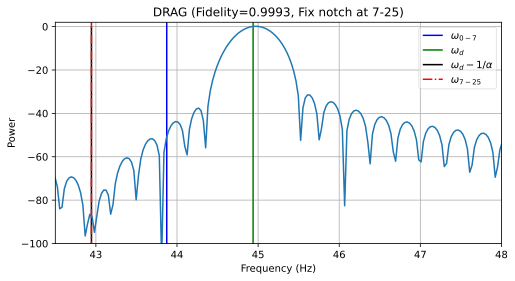

In [89]:
f, ax = plt.subplots( figsize=(8,4))
xlim = [42.5, 48]
ylim = [-100, 2]

ax.vlines(w_0_7, -120, 20, colors = "blue", linestyles = "-",  label=r"$\omega_{0-7}$")
ax.vlines(wd1, -120, 20, colors = "green", linestyles = "-",  label=r"$\omega_{d}$")
ax.vlines(wd1 - 1/alpha_guess, -120, 0, colors = "black", linestyles = "-",  label=r"$\omega_{d} - 1/\alpha$")
ax.vlines(w_7_25, -120, 20, colors = "red", linestyles = "dashdot",  label=r"$\omega_{7-25}$")
ax.plot(2*np.pi*freqs, ps_db)
ax.set_title("DRAG (Fidelity=0.9993, Fix notch at 7-25)")
ax.set_xlabel("Frequency (Hz)")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.grid()
ax.set_ylabel("Power")
ax.legend(framealpha=0.5)


#### Population integral

pop integral (25): 1.3924


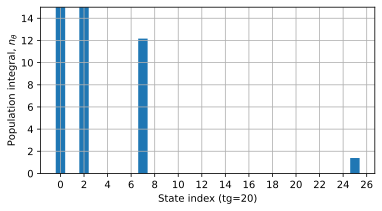

In [85]:
pop_max = []
pop_integral = []
for i in range(truc2):
    pop_integral.append( np.round( np.trapz(result[0].expect[i]), 4) )
    # print(i, hilbert_space[i], pop_integral[i])
fig, ax = plt.subplots(figsize=(6,3))
plt.bar(hilbert_space, pop_integral)
plt.ylim(0,15)
# plt.xlim(-1,50)
plt.xlabel(f'State index (tg={tg})')
plt.grid()
plt.xticks(np.arange(0, 27, 2))  # Set custom x-axis ticks
# plt.title('With drag: fidelity=%.7f'%fidelity, fontsize=15)
plt.ylabel('Population integral, $n_\\theta$')
# plt.yscale("log")
print("pop integral (25):", pop_integral[hilbert_space.index(25)])
plt.show()

#### Drag vs. No DRAG for optimized pulse

In [ ]:
tg, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B = [20, 0.374488, 0.170669, 0.240864, 0.1934, -1.264711, 0]
pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': w_trans_1 + 2*np.pi*detune_A, #w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,
        'alpha_A': alpha_A}
wd1_drag = w_trans_1 + 2*np.pi*detune_A

# pulse = np.array([ut.drive_gauss_A(t, pulse_args) for t in tlist])
# mag, freqs, peak_loc, ps_db = ut.make_power_spectrum(pulse, tlist, drive_freq=w_trans_1 + 2*np.pi*detune_A)
pulse_drag = np.array([ut.drag_A(t, pulse_args) for t in tlist])
mag_drag, freqs_drag, peak_loc_drag, ps_db_drag = ut.make_power_spectrum(pulse_drag, tlist, drive_freq=wd1_drag)
print(r'drive_freq_1 (drag) = %.3f '%(wd1_drag))


drive_freq_1 (drag) = 45.387 


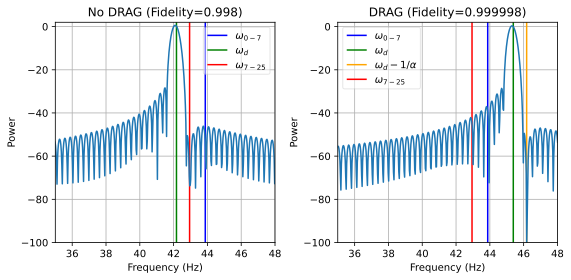

In [33]:
f, ax = plt.subplots(ncols=2, figsize=(8,4))
xlim = [35, 48]
ylim = [-100, 2]

ax[0].vlines(w_0_7, -120, 20, colors = "blue", linestyles = "-",  label=r"$\omega_{0-7}$")
ax[0].vlines(wd1, -120, 20, colors = "green", linestyles = "-",  label=r"$\omega_{d}$")
# ax[0].vlines(wd1 - 1/alpha_A, -120, 0, colors = "orange", linestyles = "-",  label=r"$\omega_{d} - 1/\alpha$")
ax[0].vlines(w_7_25, -120, 20, colors = "red", linestyles = "-",  label=r"$\omega_{7-25}$")
ax[0].plot(2*np.pi*freqs, ps_db)
ax[0].set_title("No DRAG (Fidelity=0.998)")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_xlim(*xlim)
ax[0].set_ylim(*ylim)
ax[0].grid()
ax[0].set_ylabel("Power")

ax[1].vlines(w_0_7, -120, 20, colors = "blue", linestyles = "-",  label=r"$\omega_{0-7}$")
ax[1].vlines(wd1_drag, -120, 20, colors = "green", linestyles = "-",  label=r"$\omega_{d}$")
ax[1].vlines(wd1_drag - 1/alpha_A, -120, 20, colors = "orange", linestyles = "-",  label=r"$\omega_{d} - 1/\alpha$")
ax[1].vlines(w_7_25, -120, 20, colors = "red", linestyles = "-",  label=r"$\omega_{7-25}$")
ax[1].plot(2*np.pi*freqs, ps_db_drag)
ax[1].set_title("DRAG (Fidelity=0.999998)")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_xlim(*xlim)
ax[1].set_ylim(*ylim)
ax[1].grid()
ax[1].set_ylabel("Power")

for i in range(2):
    ax[i].legend(framealpha=0.5)

plt.tight_layout();

In [ ]:
=

#### Try putting notch at $\omega_{7-25}$

In [ ]:
tg, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B = [20, 0.418621, 0.093468, 0.169464, 0.171969, 0, 0]

print("Guess for alpha", alpha_guess)
pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': wd1, #w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,
        'alpha_A': alpha_guess}
pulse_drag = np.array([ut.drag_A(t, pulse_args) for t in tlist])
mag, freqs, peak_loc, ps_db = ut.make_power_spectrum(pulse, tlist, wd1)
mag_drag, freqs_drag, peak_loc_drag, ps_db_drag = ut.make_power_spectrum(pulse_drag, tlist, wd1)

Guess for alpha 0.5017563936206957


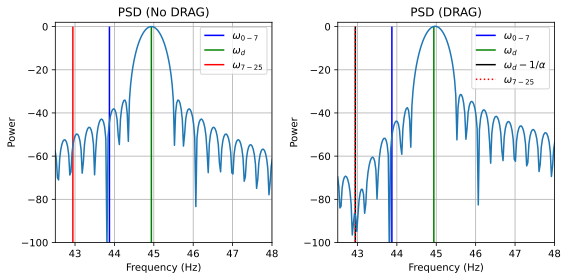

In [29]:
f, ax = plt.subplots(ncols=2, figsize=(8,4))

# xlim = [44, 47]
# ylim = [-50, 2]

xlim = [42.5, 48]
ylim = [-100, 2]

ax[0].vlines(w_0_7, -120, 0, colors = "blue", linestyles = "-", label=r"$\omega_{0-7}$")
ax[0].vlines(wd1, -120, 0, colors = "green", linestyles = "-", label=r"$\omega_{d}$")
# ax[0].vlines(drive_freq - 1/alpha_A, -120, 0, colors = "olive", linestyles = "-", label=r"$\omega_{d} - 1/\alpha$")
ax[0].vlines(w_7_25, -120, 0, colors = "red", linestyles = "-", label=r"$\omega_{7-25}$")
ax[0].plot(2*np.pi*freqs, ps_db)
ax[0].set_title("PSD (No DRAG)")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_xlim(*xlim)
ax[0].set_ylim(*ylim)
ax[0].grid()
ax[0].set_ylabel("Power")

ax[1].vlines(w_0_7, -120, 0, colors = "blue", linestyles = "-", label=r"$\omega_{0-7}$")
ax[1].vlines(wd1, -120, 0, colors = "green", linestyles = "-", label=r"$\omega_{d}$")
ax[1].vlines(wd1 - 1/alpha_guess, -120, 0, colors = "black", linestyles = "-", label=r"$\omega_{d} - 1/\alpha$")
ax[1].vlines(w_7_25, -120, 0, colors = "red", linestyles = "dotted", label=r"$\omega_{7-25}$")
ax[1].plot(2*np.pi*freqs, ps_db_drag)
ax[1].set_title("PSD (DRAG)")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_xlim(*xlim)
ax[1].set_ylim(*ylim)
ax[1].grid()
ax[1].set_ylabel("Power")

for i in range(2):
    ax[i].legend()

plt.tight_layout();

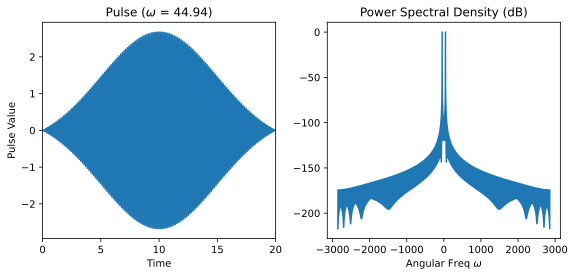

In [16]:
# Plot spectrum and pulse
f, ax = plt.subplots(ncols = 2, figsize=(8, 4))
ax[0].plot(tlist, pulse)
ax[0].set_xlim(0, tg)
# ax[1].vlines(drive_freq, -100, 1, colors = "gray", linestyles = "--")
ax[1].plot(2*np.pi*freqs, ps_db)
window = 0.5
xlim = [wd1 - window, wd1 + window]
# ax[1].set_xlim(-5, 10)
# ax[1].set_ylim(-20, 1)
# ax[1].set_ylim(np.min(ps_db[np.argmin(np.abs(2*np.pi*freqs-xlim[0])):peak_loc]),
#                0.5+ps_db[peak_loc])
ax[0].set_title(f"Pulse ($\omega$ = {np.round(wd1, 2)})")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Pulse Value")
ax[1].set_title("Power Spectral Density (dB)")
ax[1].set_xlabel(r"Angular Freq $\omega$")
plt.tight_layout();

#### Matrix element table

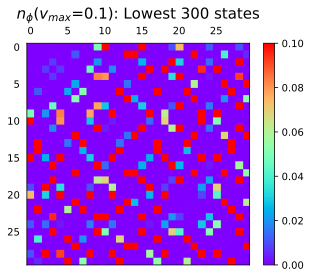

In [21]:
vmax = 0.1
truc2 = 300
fig, ax = plt.subplots(figsize=(5,4))
font_size = 15
plt.imshow(np.abs(n_phi[:truc2,:truc2]), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'$n_{\phi}$($v_{max}$='+f'{vmax}): Lowest 300 states' , pad=8,fontsize=font_size)
# ax.set_xticks(np.arange(0, truc2, 1), np.arange(0, truc2, 1), fontsize=6)
# ax.set_yticks(np.arange(0, truc2, 1), np.arange(0, truc2, 1))
# ax.set_yticks(np.arange(0, dim_plot, 1),["|0>","|1>","|2>","|3>","|4>","|5>","|6>","|7>","|8>","|9>"])
ax.xaxis.tick_top()
# ax.set_xticks(np.arange(-.5, truc2, 1), minor=True)
# ax.set_yticks(np.arange(-.5, truc2, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar()
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')